<a href="https://colab.research.google.com/github/dhadkan99/Artificial-Intelligence-and-Machine-Learning--6CS012/blob/main/Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Exercise 1
#Image Processing with Pillow and NumPy



Import Libraries

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Read and Display Image

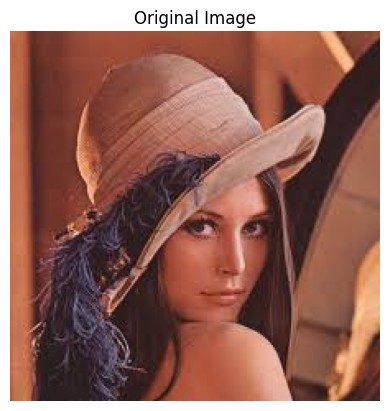

In [ ]:
img = Image.open("/content/drive/MyDrive/AI ML/Data/lena.jpg")
img_array = np.array(img)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

Display Top Left 100x100 Pixels

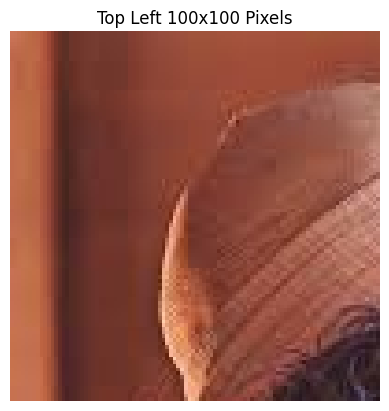

In [ ]:
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

how RGB Channels

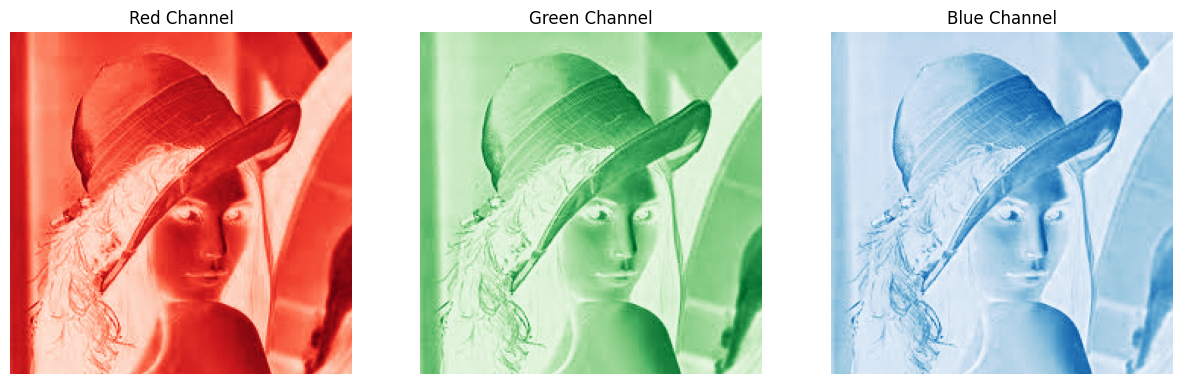

In [ ]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

Modify Top 100x100 Pixels to Value 210

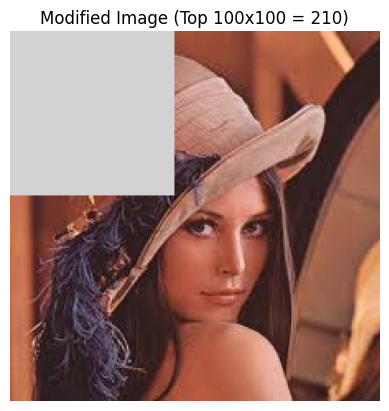

In [ ]:
modified = img_array.copy()

modified[0:100, 0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

##Exercise 2
#Grayscale Image Processing

Grayscale Image

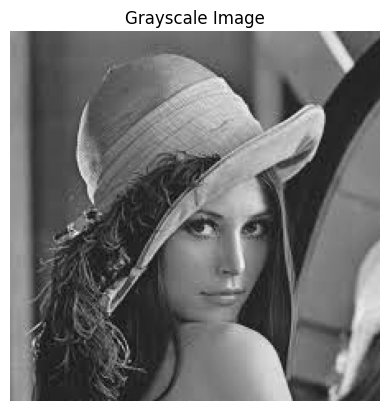

In [ ]:
gray_img = Image.open("/content/drive/MyDrive/AI ML/Data/lena.jpg").convert("L")
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Extract Middle 150 Pixels

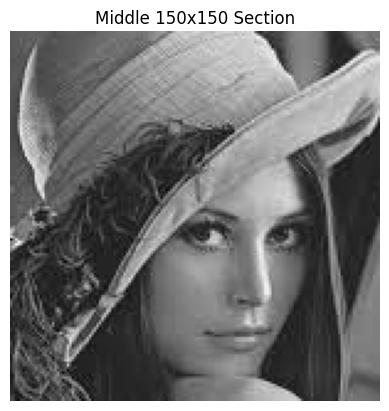

In [ ]:
h, w = gray_array.shape

center_y = h // 2
center_x = w // 2

middle = gray_array[center_y-75:center_y+75, center_x-75:center_x+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

Apply Threshold

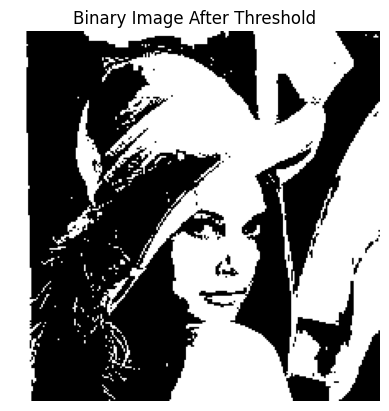

In [ ]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image After Threshold")
plt.axis("off")
plt.show()

Rotate Image 90° Clockwise

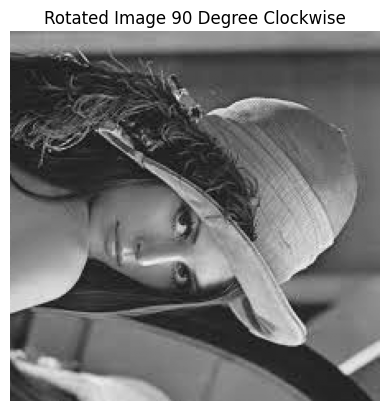

In [ ]:
rotated = np.rot90(gray_array, -1)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image 90 Degree Clockwise")
plt.axis("off")
plt.show()

Convert Grayscale to RGB

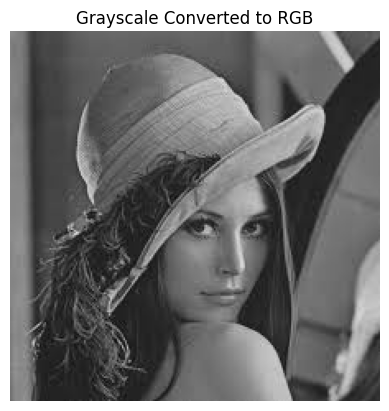

In [ ]:
rgb_img = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

##Exercise 3
#PCA Image Compression

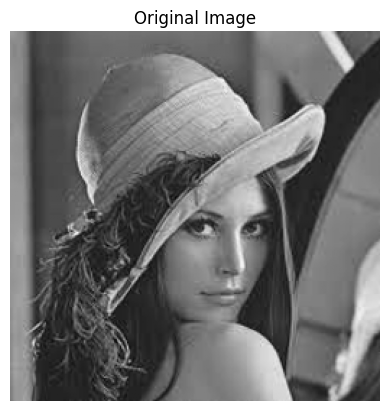

In [ ]:
img = Image.open("/content/drive/MyDrive/AI ML/Data/lena.jpg").convert("L")
img = img.resize((256,256))

data = np.array(img)

plt.imshow(data, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

Standardize Data

In [ ]:
mean = np.mean(data, axis=0)
centered = data - mean

Covariance Matrix

In [ ]:
cov_matrix = np.cov(centered, rowvar=False)

Eigen Decomposition

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

Explained Variance Plot

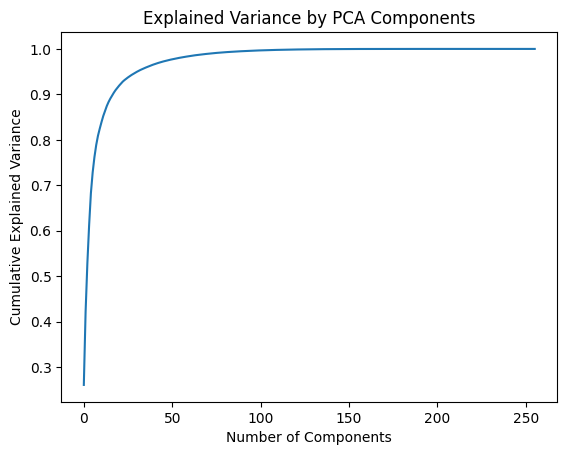

In [ ]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

Reconstruction with Different Components

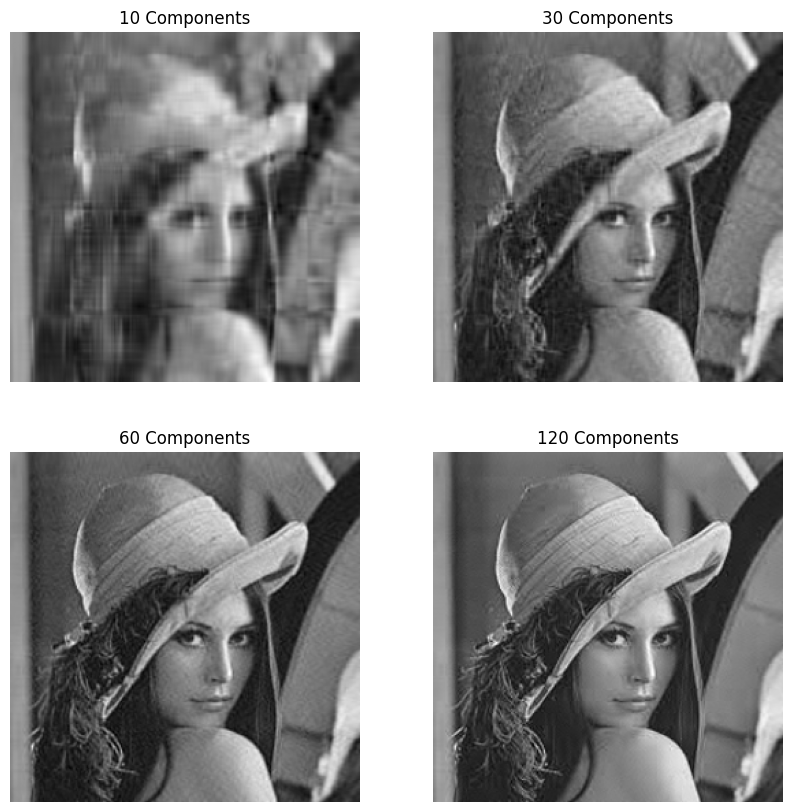

In [ ]:
components = [10, 30, 60, 120]

plt.figure(figsize=(10,10))

for i,k in enumerate(components):

    pc = eigenvectors[:, :k]

    transformed = np.dot(centered, pc)

    reconstructed = np.dot(transformed, pc.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.show()

##Evaluation
The PCA experiment shows that using fewer principal components reduces image quality, causing loss of detail and blurriness. As the number of components increases, the reconstructed image becomes clearer and more similar to the original. This demonstrates that PCA can compress images effectively while preserving the most important information.